# Data

In [1]:
history_eq_path = "./data/historico_equipos.csv"
x_path = "./data/X.csv"
y_path = "./data/Y.csv"
z_path = "./data/Z.csv"

# Dependecias

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.pyplot import axes
import numpy as np

from mlforecast import MLForecast
from mlforecast.utils import PredictionIntervals
from utilsforecast.losses import mape, smape, mae, rmse
from utilsforecast.plotting import plot_series
import statsmodels.api as sm
import seaborn as sns
import decomposer



from sklearn.linear_model import Lasso, LinearRegression, Ridge # Lasso, LinearRegression, Ridge, KNeighborsRegressor, MLPRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor

from sklearn.linear_model import LinearRegression
import lightgbm as lgb
from catboost import CatBoostRegressor
from xgboost import XGBRegressor

from utilsforecast.evaluation import evaluate

import warnings
from matplotlib import MatplotlibDeprecationWarning
warnings.filterwarnings('ignore', category=MatplotlibDeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=pd.errors.SettingWithCopyWarning)
warnings.filterwarnings('ignore', category=UserWarning)


# EDA
>

## EDA Historia Equipos

In [3]:
history_eq_df = pd.read_csv(history_eq_path)
print(history_eq_df.shape)
display(history_eq_df.head())
display(history_eq_df.describe().reset_index())
print("Column original types:")
display(history_eq_df.dtypes)
print("Null count:")
display(history_eq_df.isnull().sum())

(3530, 6)


,Date,Price_X,Price_Y,Price_Z,Price_Equipo1,Price_Equipo2
0,2010-01-04,80.12,527.5,2225.25,434.73,931.73
1,2010-01-05,80.59,527.5,2246.50,449.97,968.56
2,2010-01-06,81.89,527.5,2302.50,444.48,960.51
3,2010-01-07,81.51,527.5,2306.50,440.90,960.14
4,2010-01-08,81.37,552.5,2261.25,448.82,949.55


,index,Price_X,Price_Y,Price_Z,Price_Equipo1,Price_Equipo2
0,count,3530.000000,3530.000000,3530.000000,3530.000000,3530.000000
1,mean,78.091014,555.527108,2037.432073,460.036901,889.980408
2,std,25.186945,138.489003,373.140448,113.681273,170.042689
3,min,19.330000,257.500000,1421.500000,208.340000,566.000000
4,25%,57.052500,482.500000,1767.250000,398.227500,777.702500
5,50%,75.400000,541.625000,1974.750000,451.250000,869.785000
6,75%,104.582500,620.000000,2235.937500,515.607500,979.122500
7,max,127.980000,1062.370000,3984.000000,855.320000,1703.960000


Column original types:


Date              object
Price_X          float64
Price_Y          float64
Price_Z          float64
Price_Equipo1    float64
Price_Equipo2    float64
dtype: object

Null count:


Date             0
Price_X          0
Price_Y          0
Price_Z          0
Price_Equipo1    0
Price_Equipo2    0
dtype: int64

### Analisis de columna de tiempo

In [4]:
history_eq_df['Date'] = pd.to_datetime(history_eq_df['Date'])
min_date = history_eq_df['Date'].min()
print(f"Min Date: {min_date}")
max_date = history_eq_df['Date'].max()
print(f"Max Date: {max_date}")


date_diff = max_date - min_date
years = date_diff.days // 365
months = (date_diff.days % 365) // 30
days = (date_diff.days % 365) % 30
print(f"Date difference: {years} years, {months} months, {days} days")

freq = pd.infer_freq(history_eq_df['Date'])
print(f"Infered frequency: {freq}")

Min Date: 2010-01-04 00:00:00
Max Date: 2023-08-31 00:00:00
Date difference: 13 years, 8 months, 2 days
Infered frequency: None


Frecuencia None sugiere posiblemente filas con fechas repetidas o fechas faltantes, lo que interrupe en uno o varios puntos la frecuencia Diaria, sugerida a primera vista de la data. Una inspeccion manual de los datos  debemos hacer un test de consistencia de los timestamps

In [5]:

duplicated = history_eq_df[history_eq_df.duplicated(subset=['Date'], keep=False)]
print(f"duplicated dates rows: {duplicated.shape[0]}")

print('\ngaps')
display(history_eq_df['Date'].diff().value_counts())

duplicated dates rows: 0

gaps


Date
1 days    2808
3 days     687
4 days      25
2 days       9
Name: count, dtype: int64

<Axes: >

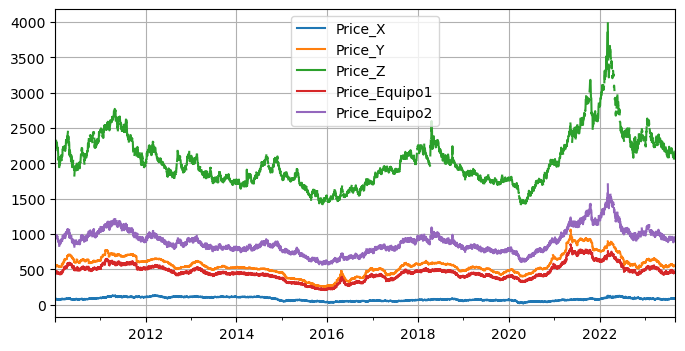

In [6]:
history_eq_df = history_eq_df.set_index('Date')
complete_index = pd.date_range(start=min_date, end=max_date, freq='D')
history_eq_df = history_eq_df.reindex(complete_index)
history_eq_df.sort_index(inplace=True)
history_eq_df.plot(figsize=(8, 4), grid=True)

concetrar la grafica en 2022, para tener una muestra del comportamiento de los saltos temporales

<Axes: >

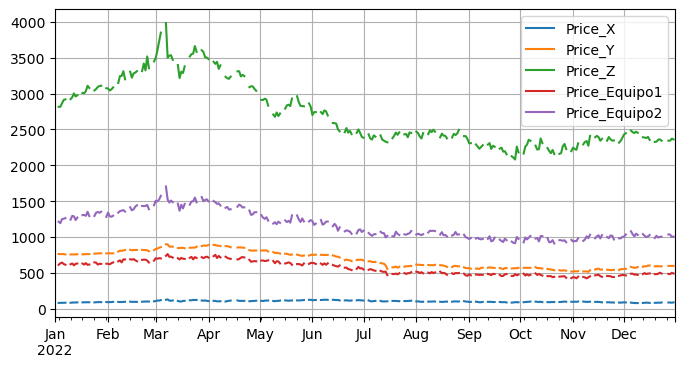

In [7]:
history_eq_df.loc['2022-01-01':'2022-12-31'].plot(figsize=(8, 4), grid=True)

#### llenar vacios temporales
la anterior grafica sugiere que una forma de llenar los vacios temporales puede ser la intepolacion entre puntos que separan los vacios con un metodo lineal

In [8]:
history_eq_df = history_eq_df.interpolate(method='linear')


freq = pd.infer_freq(history_eq_df.index)
print(f"Infered frequency after reindexing: {freq}")

print(f"new dataframe shape: {history_eq_df.shape}")

Infered frequency after reindexing: D
new dataframe shape: (4988, 5)


<Axes: >

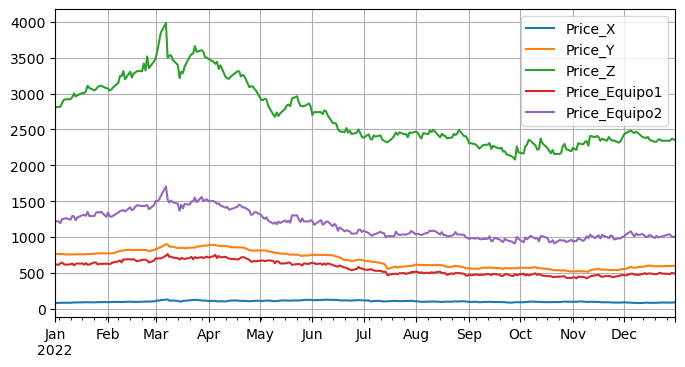

In [9]:
history_eq_df.loc['2022-01-01':'2022-12-31'].plot(figsize=(8, 4), grid=True)

## Analisis estadistico de variables target y features


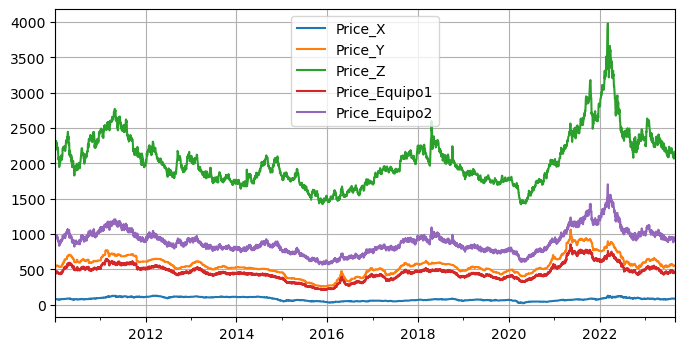

In [10]:
history_eq_df.sort_index(inplace=True)
history_eq_df.plot(figsize=(8, 4), grid=True)
plt.show()

### Distributions Comparison

#### skewness & kurtosis

In [11]:

for col in history_eq_df.columns:
    print(f"Skewness of {col}: {history_eq_df[col].skew()}")
print("\n")
for col in history_eq_df.columns:
    print(f"Kurtosis of {col}: {history_eq_df[col].kurtosis()}")
        

Skewness of Price_X: 0.08224821266435678
Skewness of Price_Y: 0.4768885382027185
Skewness of Price_Z: 1.1451647384348107
Skewness of Price_Equipo1: 0.4059688020618139
Skewness of Price_Equipo2: 0.8412790272479774


Kurtosis of Price_X: -1.1453946686916705
Kurtosis of Price_Y: 0.7271416283793326
Kurtosis of Price_Z: 2.042617219831026
Kurtosis of Price_Equipo1: 0.582845454185462
Kurtosis of Price_Equipo2: 1.104114702865207


#### Equipo1 vs Features

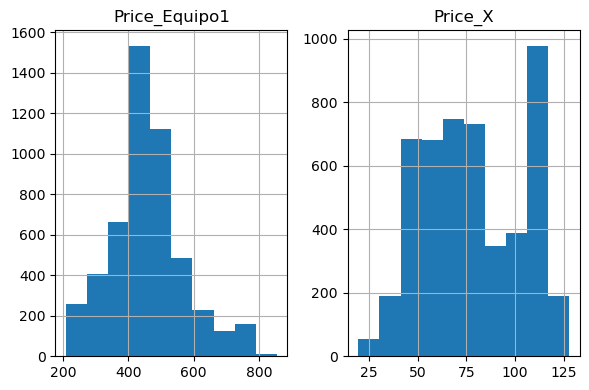

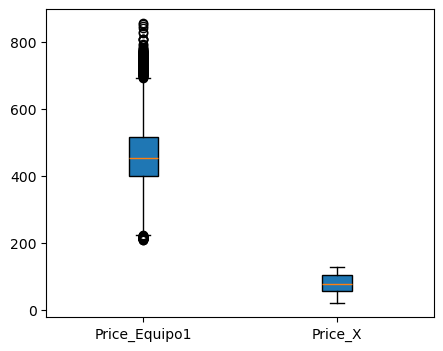

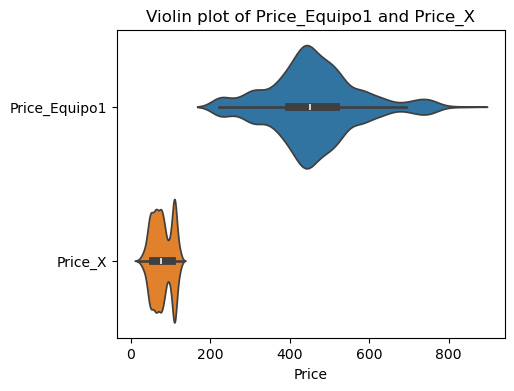

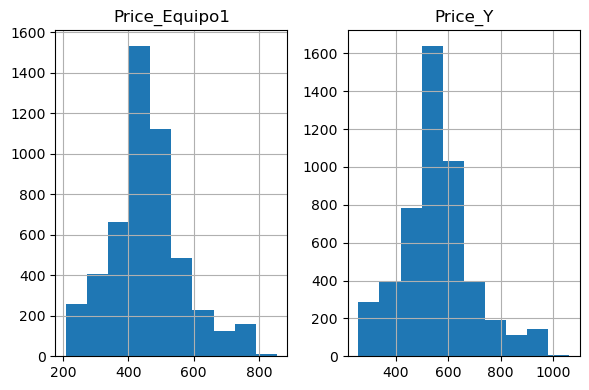

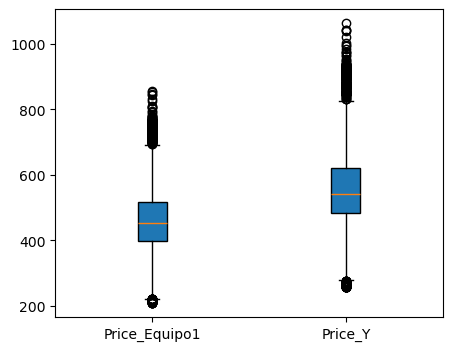

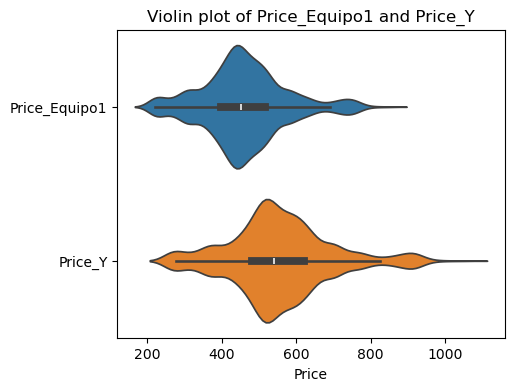

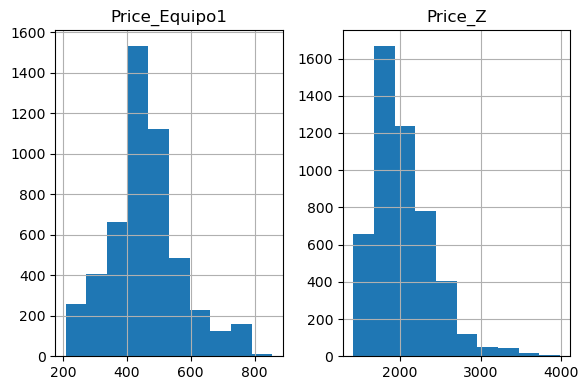

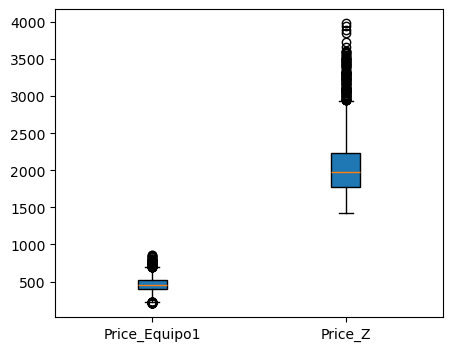

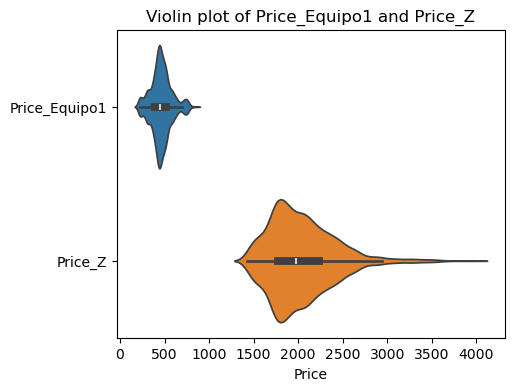

In [12]:
features = ['Price_X', 'Price_Y', 'Price_Z']
# Equipo 1
for col in features:
    compare = ['Price_Equipo1', col]
    history_eq_df[compare].hist(figsize=(6, 4))
    plt.tight_layout()
    plt.show()
    plt.figure(figsize=(5, 4))
    plt.boxplot(history_eq_df[compare], vert=True, patch_artist=True, labels=compare)
    plt.show()

    #violin plot
    plt.figure(figsize=(5, 4))
    sns.violinplot(data=history_eq_df[compare], orient='h')
    plt.title(f'Violin plot of {compare[0]} and {compare[1]}')
    plt.xlabel('Price')
    plt.show()
   


#### Equipo2 vs Features

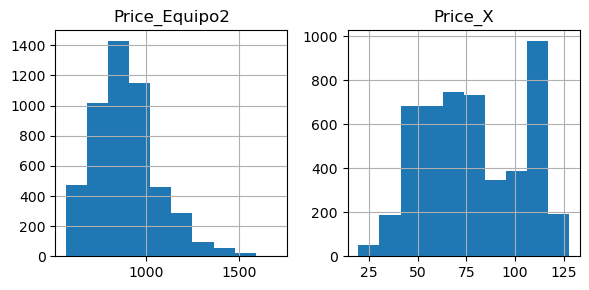

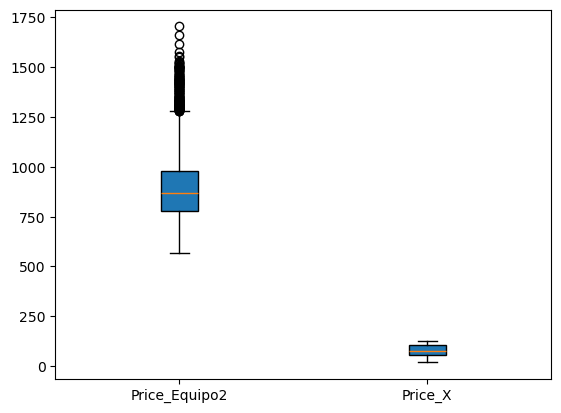

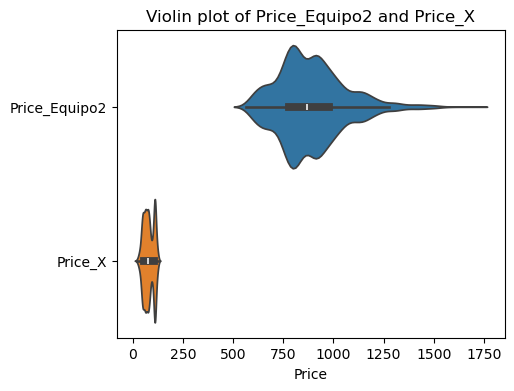

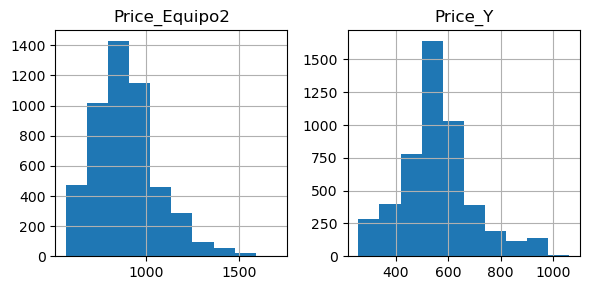

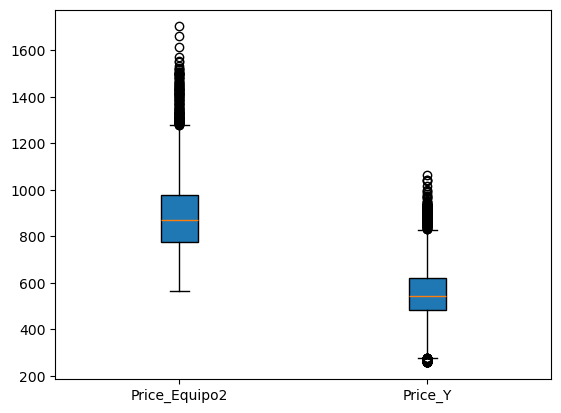

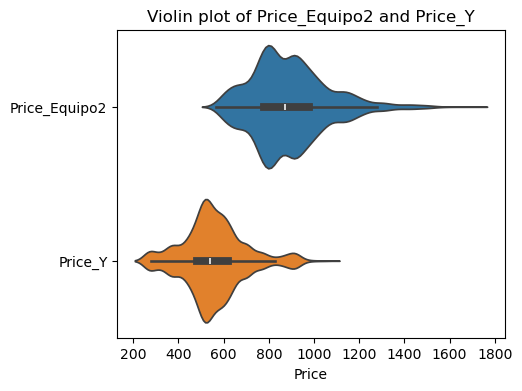

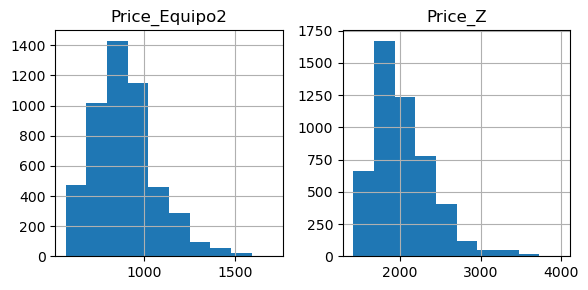

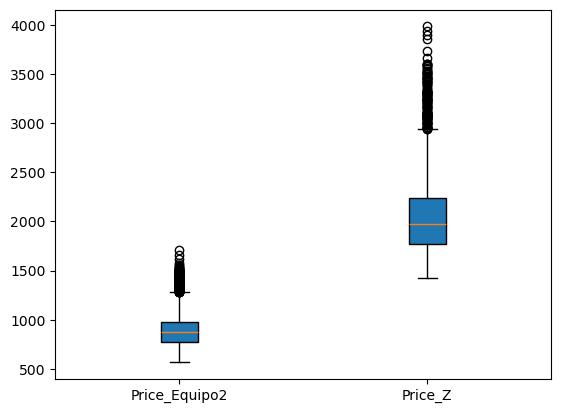

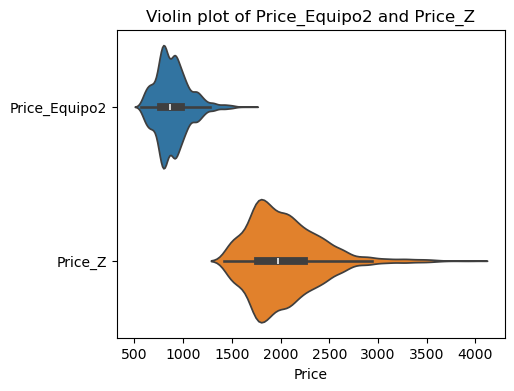

In [13]:

# Equipo 1
for col in features:
    compare = ['Price_Equipo2', col]
    history_eq_df[compare].hist(figsize=(6, 3))
    plt.tight_layout()
    plt.show()
    plt.boxplot(history_eq_df[compare], vert=True, patch_artist=True, labels=compare)
    plt.show()

     #violin plot
    plt.figure(figsize=(5, 4))
    sns.violinplot(data=history_eq_df[compare], orient='h')
    plt.title(f'Violin plot of {compare[0]} and {compare[1]}')
    plt.xlabel('Price')
    plt.show()



####  Q-Q plots

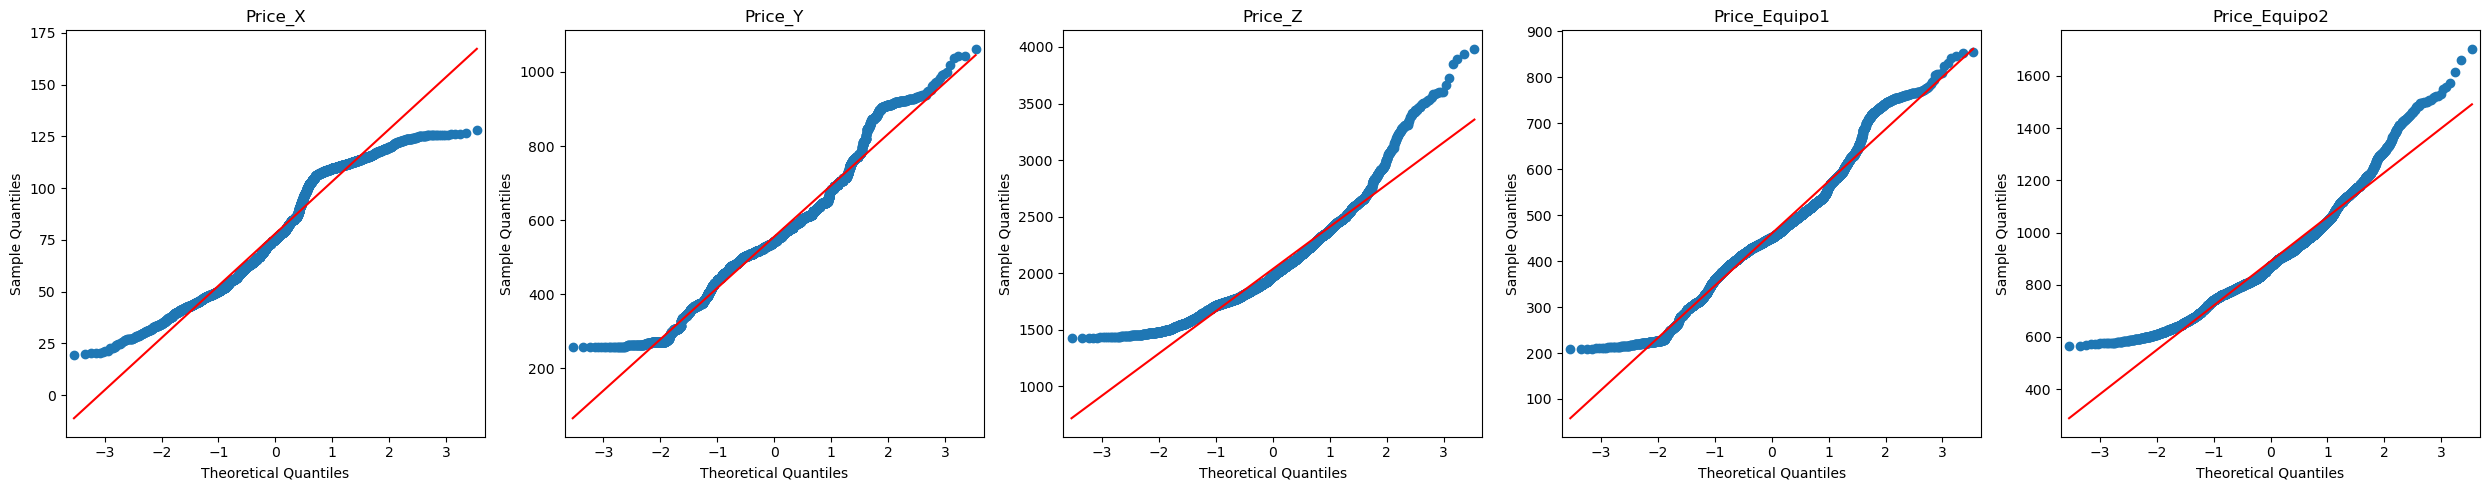

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, col in enumerate(history_eq_df.columns):
    if i == 0 and len(history_eq_df.columns) != len(np.atleast_1d(axes)):
        plt.close(fig)
        fig, axes = plt.subplots(1, len(history_eq_df.columns), figsize=(5 * len(history_eq_df.columns), 5))
    sm.qqplot(history_eq_df[col], line='s', ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()


### Descompoiscion Seasonal Multiple de series de tiempo

Decomposition of column: Price_X
Decomposition of column: Price_Y
Decomposition of column: Price_Z
Decomposition of column: Price_Equipo1
Decomposition of column: Price_Equipo2


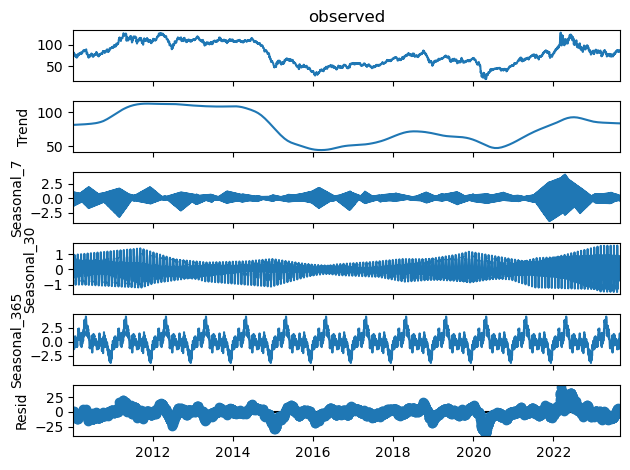

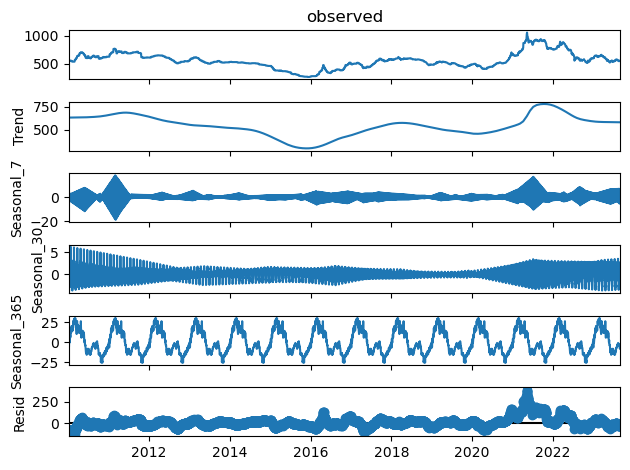

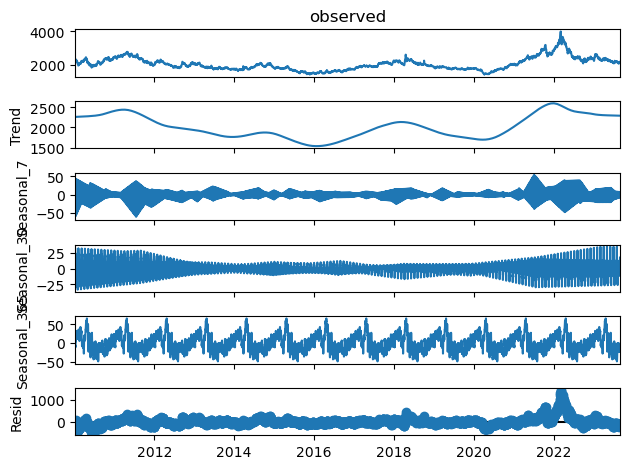

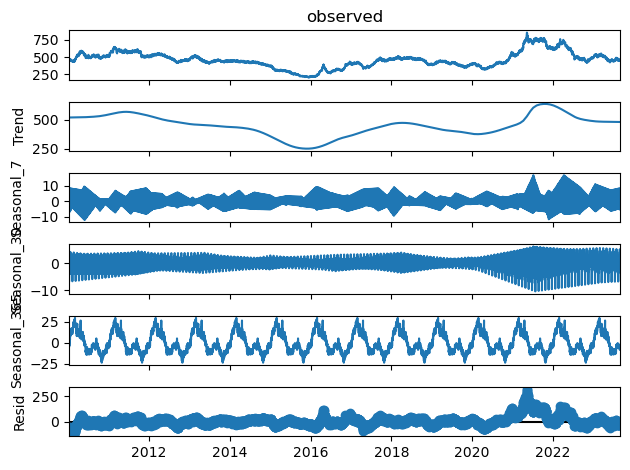

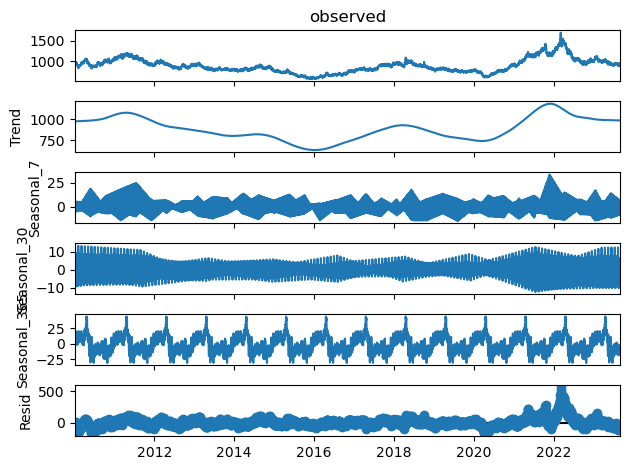

In [15]:
for col in history_eq_df.columns:
    print("Decomposition of column:", col)
    decomposer.Decomposer.mstl_decomposition_plot(history_eq_df[col], 'D', ['W','M','Y'])

### Descomposicion Seasonal simple de Series temporales: Patrones Anuales

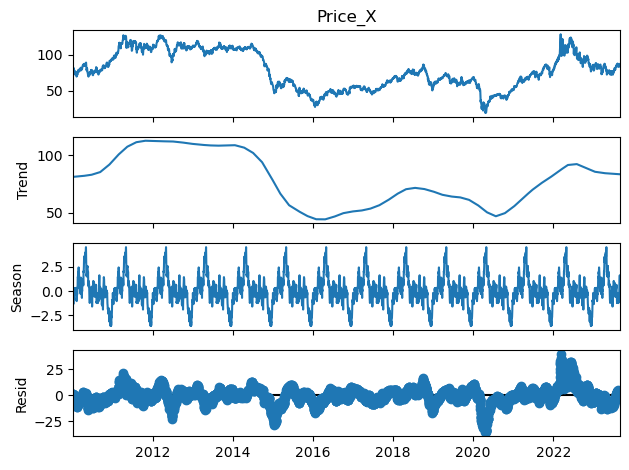

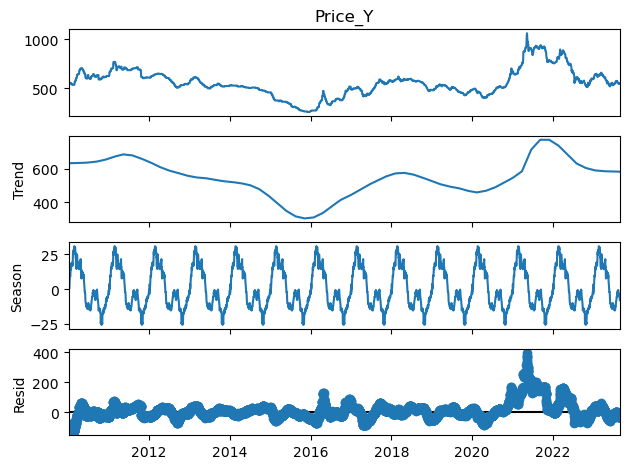

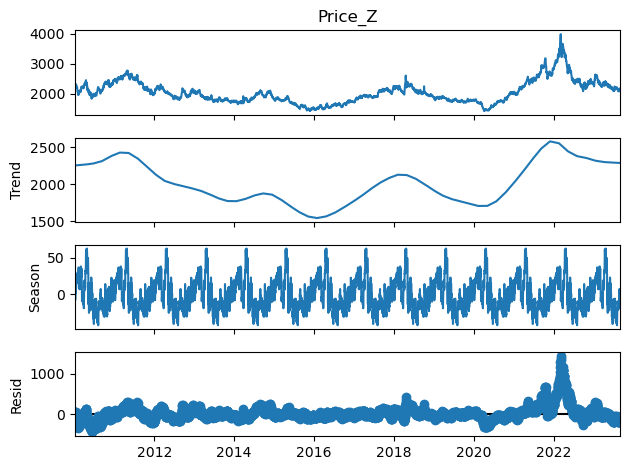

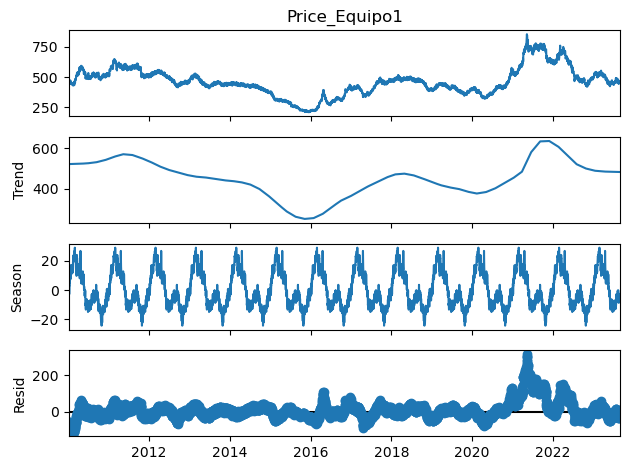

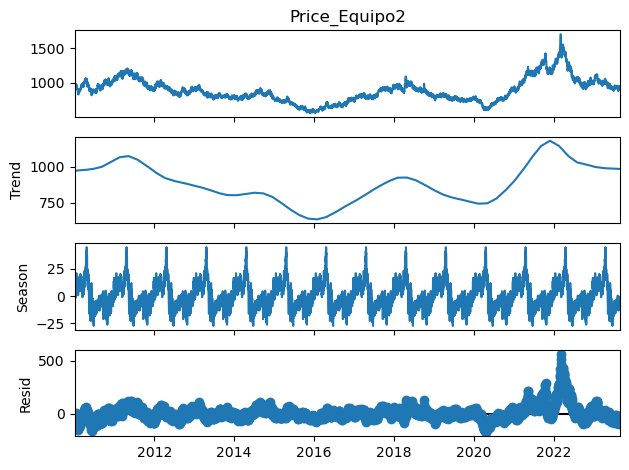

In [16]:
decomposed_series = {}
for col in history_eq_df.columns:
    decomposer.Decomposer.stl_decomposition_plot(history_eq_df[col], 'D', 'Y')
    decomposed_series[col] = decomposer.Decomposer.series_stl_decomposition(history_eq_df[col], 'D', 'Y')

## Validacion de fuentes externas X,Y,Z

### X 

In [17]:
x_df = pd.read_csv(x_path)

print(x_df.shape)
display(x_df.head())
display(x_df.describe())
print("Column original types:")
display(x_df.dtypes)
print("Null count:")
display(x_df.isnull().sum())



x_df = x_df.rename(columns={"Price": "original_price_X"})

x_df['Date'] = pd.to_datetime(x_df['Date'])

x_df = x_df.set_index('Date')
print('min_date_x: ', x_df.index.min())
print('max_date_x: ', x_df.index.max())


(9144, 2)


,Date,Price
0,2024-04-04,89.18
1,2024-04-03,89.35
2,2024-04-02,88.92
3,2024-04-01,87.42
4,2024-03-28,87.48


,Price
count,9144.000000
mean,51.323922
std,32.994964
min,9.640000
25%,19.687500
50%,45.940000
75%,75.207500
max,146.080000


Column original types:


Date      object
Price    float64
dtype: object

Null count:


Date     0
Price    0
dtype: int64

min_date_x:  1988-06-27 00:00:00
max_date_x:  2024-04-04 00:00:00


equal_prices_X    1
dtype: int64


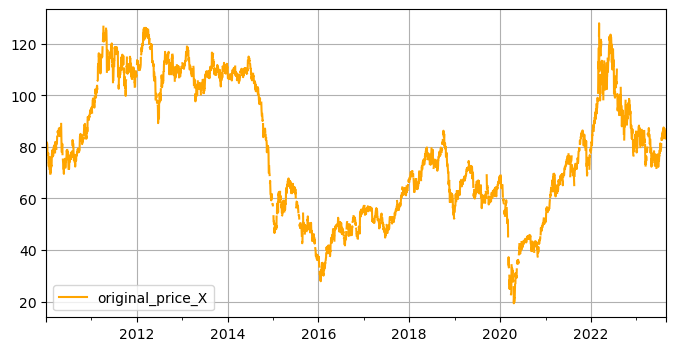

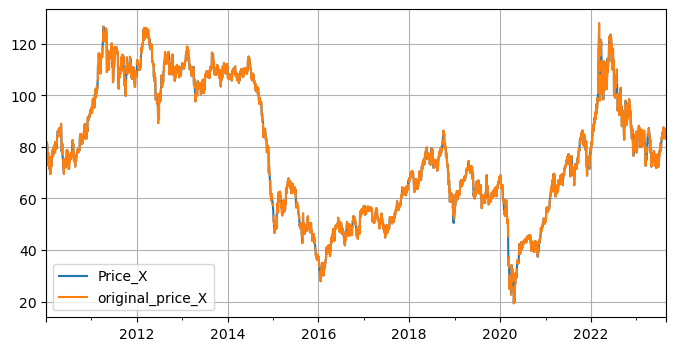

In [18]:
x_df.sort_index(inplace=True)
x_df = x_df.loc[min_date:max_date]  #global data range

combined_x_df = history_eq_df[['Price_X']].join(x_df, how='left')

combined_x_df[['original_price_X']].plot(figsize=(8, 4), grid=True, color='orange')

combined_x_df.plot(figsize=(8, 4), grid=True )

combined_x_df['original_price_X'] = combined_x_df['original_price_X'].interpolate(method='linear')

combined_x_df['equal_prices_X'] = combined_x_df["Price_X"] == combined_x_df["original_price_X"]
print(combined_x_df[['equal_prices_X']].nunique())


### Y

In [19]:
y_df = pd.read_csv(y_path, sep=';')

y_df['Date'] = pd.to_datetime(y_df['Date'], format="%d/%m/%Y")
y_df['Price'] = y_df['Price'].str.replace(',', '.')
y_df['Price'] = pd.to_numeric(y_df['Price'], errors='coerce')

print(y_df.shape)
display(y_df.head())
display(y_df.describe())
print("Column original types:")
display(y_df.dtypes)
print("Null count:")
display(y_df.isnull().sum())

y_df = y_df.rename(columns={"Price": "original_price_Y"})

y_df = y_df.set_index('Date')

print('min_date_y: ', y_df.index.min())
print('max_date_y: ', y_df.index.max())

(4485, 2)


,Date,Price
0,2023-09-12,547.33
1,2023-09-11,546.00
2,2023-09-08,545.00
3,2023-09-07,550.00
4,2023-09-06,552.50


,Date,Price
count,4485,4485.000000
mean,2015-02-08 13:59:55.183946496,565.458283
min,2006-07-11 00:00:00,257.500000
25%,2010-10-26 00:00:00,485.000000
50%,2015-02-09 00:00:00,543.670000
75%,2019-05-27 00:00:00,617.670000
max,2023-09-12 00:00:00,1062.370000
std,NaN,145.150530


Column original types:


Date     datetime64[ns]
Price           float64
dtype: object

Null count:


Date     0
Price    0
dtype: int64

min_date_y:  2006-07-11 00:00:00
max_date_y:  2023-09-12 00:00:00


equal_prices_Y    2
dtype: int64


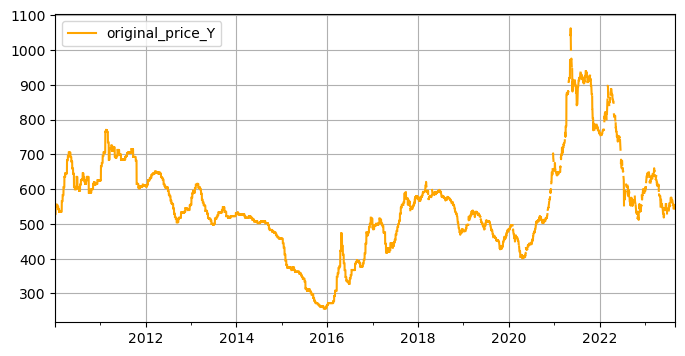

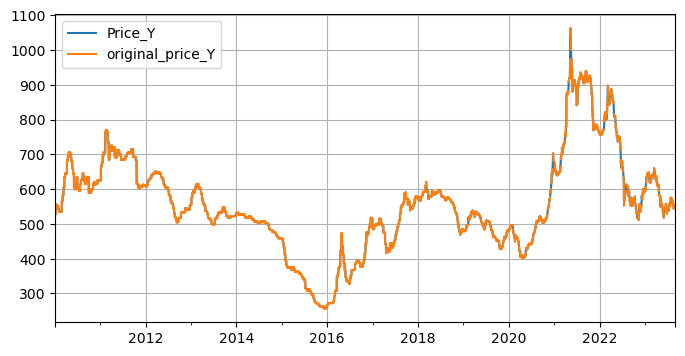

In [20]:
y_df.sort_index(inplace=True)
y_df = y_df.loc[min_date:max_date] #global data range
combined_y_df = history_eq_df[['Price_Y']].join(y_df, how='left')

combined_y_df[[ 'original_price_Y']].plot(figsize=(8, 4), grid=True, color='orange')
combined_y_df.plot(figsize=(8, 4), grid=True, )

combined_y_df['original_price_Y'] = combined_y_df['original_price_Y'].interpolate(method='linear')

combined_y_df['equal_prices_Y'] = combined_y_df["Price_Y"] == combined_y_df["original_price_Y"]
print(combined_y_df[['equal_prices_Y']].nunique())


para la variable Y la interpolacion de los espacios en la data del archivo Y.csv, no corresponde con la interpolacion de los espacios en la data consolidada del historico de equipos. lo que indica que la data usada para el historico equipos estaba mas completa. pero cuando coiciden en terminos de fechas los valores de precios tambien son consistentes entre bases de datos

### Z

In [21]:
z_df = pd.read_csv(z_path)
z_df['Date'] = pd.to_datetime(z_df['Date'])
z_df['Price'] = pd.to_numeric(z_df['Price'], errors='coerce')

print(z_df.shape)
display(z_df.head())
display(z_df.describe())
print("Column original types:")
display(z_df.dtypes)
print("Null count:")
display(z_df.isnull().sum())


z_df = z_df.rename(columns={"Price": "original_price_Z"})

z_df = z_df.set_index('Date')


print('min_date_z: ', z_df.index.min())
print('max_date_z: ', z_df.index.max())

(3565, 2)


,Price,Date
0,2225.25,2010-01-01
1,2225.25,2010-01-04
2,2246.50,2010-01-05
3,2302.50,2010-01-06
4,2306.50,2010-01-07


,Price,Date
count,3565.000000,3565
mean,2037.081197,2016-10-31 14:23:59.999999744
min,1421.500000,2010-01-01 00:00:00
25%,1767.500000,2013-06-03 00:00:00
50%,1974.750000,2016-11-01 00:00:00
75%,2235.750000,2020-04-01 00:00:00
max,3984.000000,2023-08-31 00:00:00
std,372.976076,NaN


Column original types:


Price           float64
Date     datetime64[ns]
dtype: object

Null count:


Price    0
Date     0
dtype: int64

min_date_z:  2010-01-01 00:00:00
max_date_z:  2023-08-31 00:00:00


In [22]:
z_df.sort_index(inplace=True)
z_df = z_df.loc[min_date:max_date]  #global data range  

equal_prices_Z    2
dtype: int64


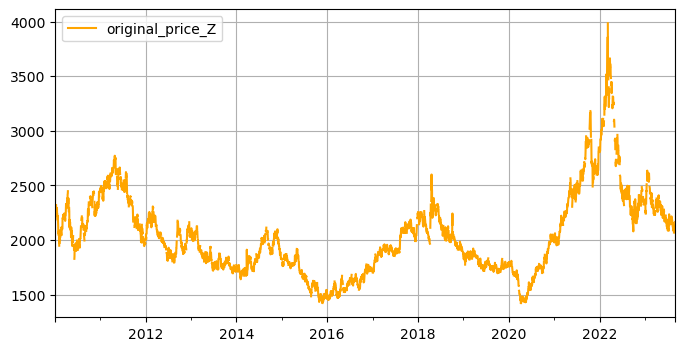

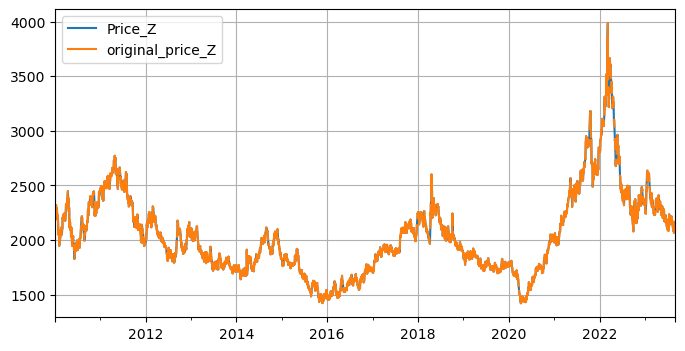

In [23]:
combined_z_df = history_eq_df[['Price_Z']].join(z_df, how='left')

combined_z_df[['original_price_Z']].plot(figsize=(8, 4), grid=True, color='orange')
combined_z_df.plot(figsize=(8, 4), grid=True, )

combined_z_df['original_price_Z'] = combined_z_df['original_price_Z'].interpolate(method='linear')

combined_z_df['equal_prices_Z'] = combined_z_df["Price_Z"] == combined_z_df["original_price_Z"]
print(combined_z_df[['equal_prices_Z']].nunique())

# Correlation Analisys



## Equipo 1 ~ features

,Price_X,Price_Y,Price_Z,Price_Equipo1
Price_X,1.000000,0.492274,0.476217,0.524724
Price_Y,0.492274,1.000000,0.844424,0.996937
Price_Z,0.476217,0.844424,1.000000,0.844392
Price_Equipo1,0.524724,0.996937,0.844392,1.000000


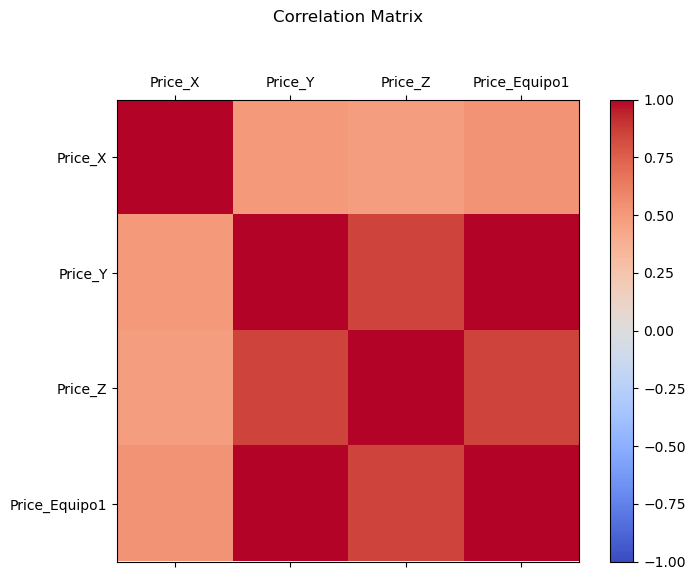

In [24]:
eq_1_cols = history_eq_df.columns.tolist()
eq_1_cols.remove('Price_Equipo2')
eq_1_df = history_eq_df[eq_1_cols]

corr_matrix_eq_1 = eq_1_df.corr()
display(corr_matrix_eq_1)

# Plot using matshow
fig, ax = plt.subplots(figsize=(8, 6))
cax = ax.matshow(corr_matrix_eq_1, cmap='coolwarm', vmin=-1, vmax=1)
fig.colorbar(cax)

# Set up the labels
ticks = range(len(eq_1_df.columns))
ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.set_xticklabels(eq_1_df.columns)
ax.set_yticklabels(eq_1_df.columns)

plt.title("Correlation Matrix", y=1.15)
plt.show()

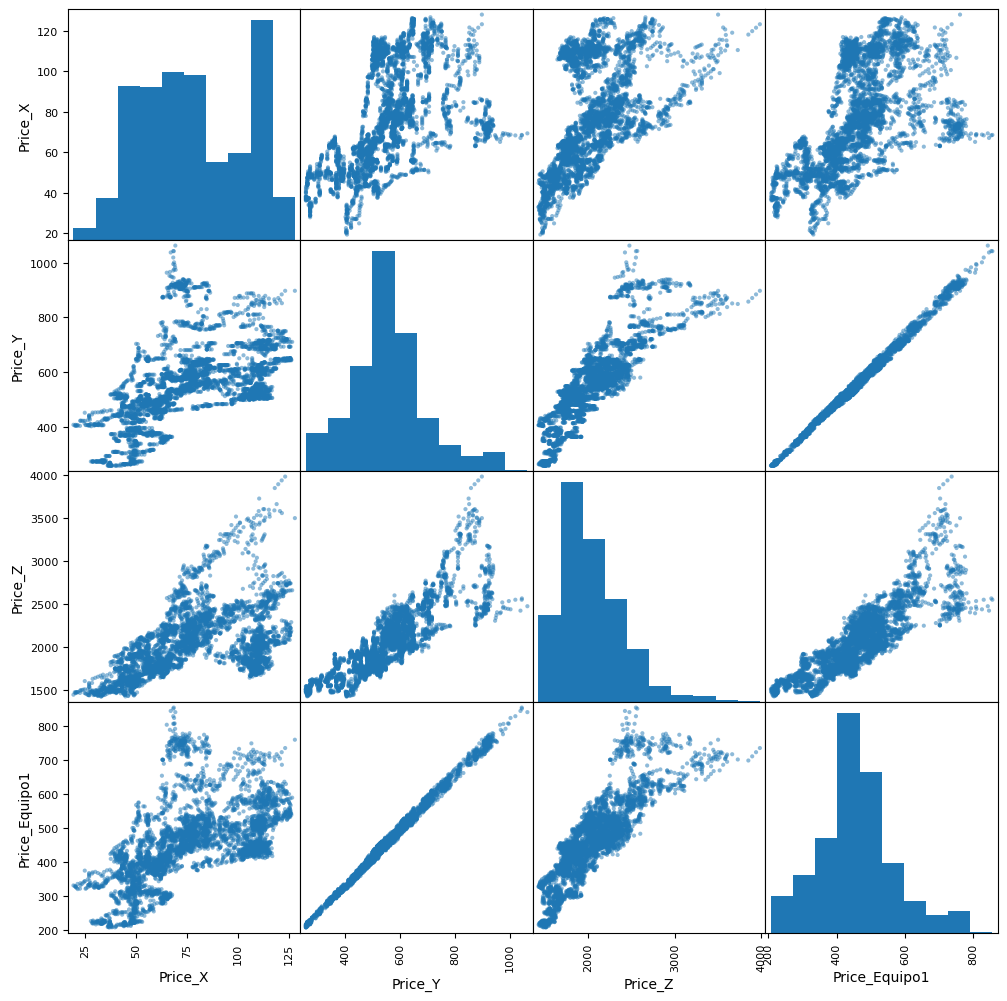

In [25]:
pd.plotting.scatter_matrix(eq_1_df, figsize=(12, 12))
plt.show()

las graficas para el equipo 1 sugiere que la variable con mayor correlacion es price_Y, pues hay una colinealidad positiva fuerte (coeficiente pearson cercano a 1). podemos investigar a fondo esta relacion

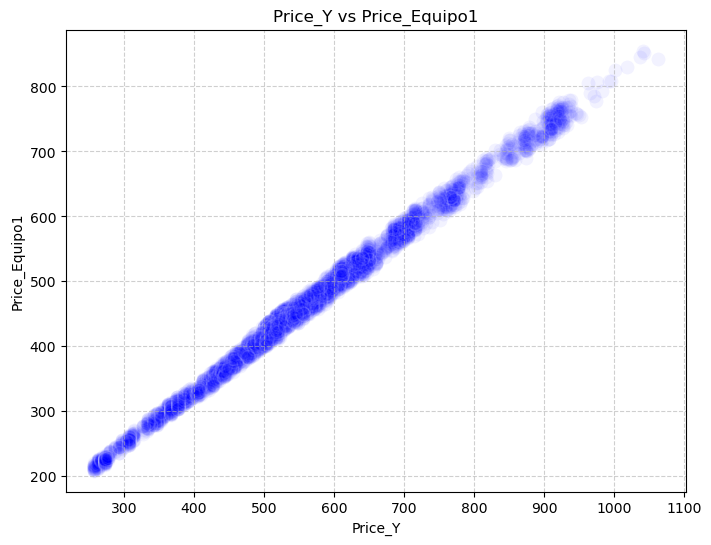

In [26]:
plt.figure(figsize=(8, 6))
plt.scatter(eq_1_df['Price_Y'], eq_1_df['Price_Equipo1'], alpha=0.05, c='blue', edgecolors='w', s=100)

plt.title('Price_Y vs Price_Equipo1')
plt.xlabel('Price_Y')
plt.ylabel('Price_Equipo1')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

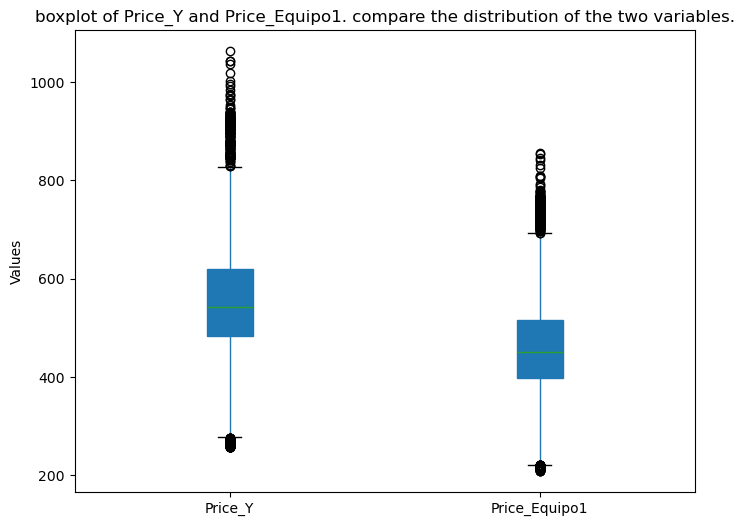

In [27]:
plt.figure(figsize=(8, 6))

# Use the column parameter to specify which variables to plot
eq_1_df.boxplot(column=['Price_Y', 'Price_Equipo1'], grid=False, patch_artist=True)

plt.title('boxplot of Price_Y and Price_Equipo1. compare the distribution of the two variables.')
plt.ylabel('Values')
plt.show()

## Equipo 2 ~ features

,Price_X,Price_Y,Price_Z,Price_Equipo2
Price_X,1.000000,0.492274,0.476217,0.531270
Price_Y,0.492274,1.000000,0.844424,0.913345
Price_Z,0.476217,0.844424,1.000000,0.983265
Price_Equipo2,0.531270,0.913345,0.983265,1.000000


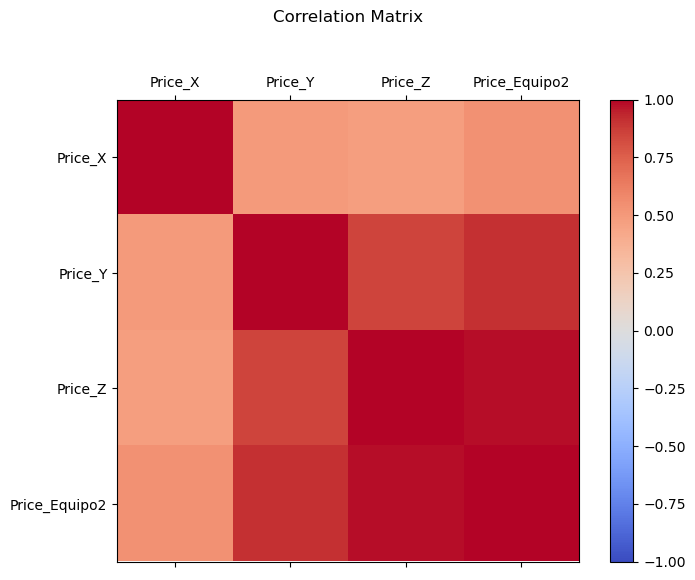

In [28]:
eq_2_cols = history_eq_df.columns.tolist()
eq_2_cols.remove('Price_Equipo1')
eq_2_df = history_eq_df[eq_2_cols]

corr_matrix_eq_2 = eq_2_df.corr()
display(corr_matrix_eq_2)

# Plot using matshow
fig, ax = plt.subplots(figsize=(8, 6))
cax = ax.matshow(corr_matrix_eq_2, cmap='coolwarm', vmin=-1, vmax=1)
fig.colorbar(cax)

# Set up the labels
ticks = range(len(eq_2_df.columns))
ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.set_xticklabels(eq_2_df.columns)
ax.set_yticklabels(eq_2_df.columns)

plt.title("Correlation Matrix", y=1.15)
plt.show()

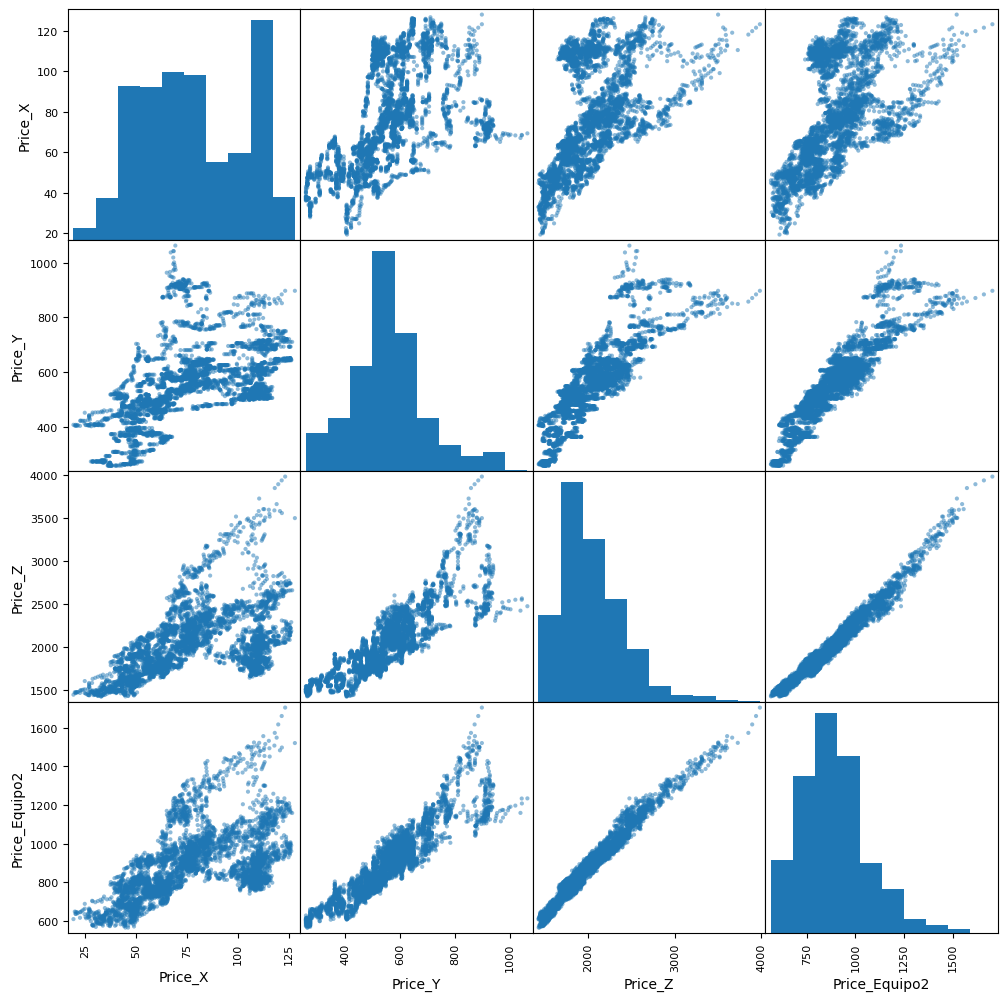

In [29]:
pd.plotting.scatter_matrix(eq_2_df, figsize=(12, 12))
plt.show()

### Modeling parameters

In [30]:
future_horizon = 30
optimization_metric = 'smape'

# Feature Enginerring & Preparacion de Datos



lo que el EDA nos sugiere es que los insumos Y y Z son mas relevantes para explicar el comportamiento de las variables Equipo1 y Equipo 2 respectivamente.



In [31]:
exog_features = ['Price_Y', 'Price_Z']
targets = ['Price_Equipo1', 'Price_Equipo2']

tambien crearemos una metodologia de evaluacion con las mismas condiciones de crossvalidation para diferentes metodos estadisticos o de ML

optimizando el proceso de seleccion con un parametro de future_horizon, para ajustarse a diversos escenarios practicos o necesidades de prediccion que el negocio puediera requerir

In [32]:
history = history_eq_df[targets + exog_features]
history.reset_index(inplace=True, names='Date')

#### Decomposicion seasonal

In [33]:
seasonal_features = []
for col in exog_features+targets:
    history['seasonal_'+col] =  decomposed_series[col]['d_stl_seasonal_dfreq_D_sfreq_Y_robust_True_degree_0_optimized_True'].values
    seasonal_features.append('seasonal_'+col)
display(history[history['Date']>'2011-02-01'])

,Date,Price_Equipo1,Price_Equipo2,Price_Y,Price_Z,seasonal_Price_Y,seasonal_Price_Z,seasonal_Price_Equipo1,seasonal_Price_Equipo2
394,2011-02-02,578.790000,1107.060000,705.000000,2522.250000,18.603789,22.920144,12.249863,5.399759
395,2011-02-03,579.990000,1089.250000,705.000000,2515.500000,18.876592,18.520412,17.002086,6.619015
396,2011-02-04,569.740000,1116.950000,705.000000,2523.250000,18.530252,15.023339,13.631758,1.051009
397,2011-02-05,575.356667,1110.596667,705.000000,2528.500000,18.756402,27.128051,11.316980,10.194082
398,2011-02-06,580.973333,1104.243333,705.000000,2533.750000,18.487060,24.566061,15.339247,15.091098
...,...,...,...,...,...,...,...,...,...
4983,2023-08-27,462.806667,922.016667,550.666667,2118.666667,-6.102132,-5.929486,-5.182759,-9.896584
4984,2023-08-28,469.030000,933.200000,549.000000,2116.250000,-6.395355,-1.106622,-4.140811,-5.062308
4985,2023-08-29,460.420000,901.790000,545.330000,2116.250000,-7.149983,-8.797623,-7.684506,-8.618742
4986,2023-08-30,464.800000,945.400000,543.670000,2140.250000,-7.594363,-10.547897,-7.199001,-8.206419


#### Prepar Datos y crear Lags de features

In [34]:


def prepare_data(df, target_cols, p_exog_features, lookback_days, date_col='Date'):

    df = df.copy()

    lagged_features = []

    future_lags = pd.DataFrame()

    last_date = df[date_col].max()
    future_dates = pd.date_range(start=last_date, periods=future_horizon + 1, freq=freq)[1:]
    
    future_df = pd.DataFrame({date_col: future_dates})
    df_extended = pd.concat([df, future_df], ignore_index=True)
    
    lagged_features = []


    for feature in p_exog_features:
        for lookback in lookback_days:
            lagged_col_name = f'{feature}_lookback_{lookback}'
            df_extended[lagged_col_name] = df_extended[feature].shift(lookback)
            lagged_features.append(lagged_col_name)

    future_mask = df_extended[date_col].isin(future_dates)

    future_lags = df_extended.loc[future_mask, [date_col] + lagged_features]
    future_lags = future_lags.rename(columns={date_col: 'ds'})

    history_df = df_extended.loc[~future_mask].copy()
    history_df = history_df.dropna(subset=target_cols + lagged_features).reset_index(drop=True)


    long_df = history_df.melt(
        id_vars=[date_col] + lagged_features + seasonal_features,
        value_vars=target_cols, # 'Price_Equipo1', 'Price_Equipo2'
        var_name='unique_id',
        value_name='y'
    )
    long_df = long_df.rename(columns={date_col: 'ds'})
    
    return long_df, lagged_features, future_lags

history_augmented, lagged, future_lags = prepare_data(history, ['Price_Equipo1', 'Price_Equipo2'], ['Price_Y', 'Price_Z'], lookback_days=[365])
display(history_augmented)
print(lagged)

,ds,Price_Y_lookback_365,Price_Z_lookback_365,seasonal_Price_Y,seasonal_Price_Z,seasonal_Price_Equipo1,seasonal_Price_Equipo2,unique_id,y
0,2011-01-04,527.50,2225.25,-3.586152,7.704693,-1.714597,5.216202,Price_Equipo1,522.290000
1,2011-01-05,527.50,2246.50,-1.420028,-3.597647,-1.481029,-3.308660,Price_Equipo1,534.360000
2,2011-01-06,527.50,2302.50,-1.723436,7.662662,-3.338756,1.765682,Price_Equipo1,507.700000
3,2011-01-07,527.50,2306.50,3.523073,-2.813560,4.364234,1.800659,Price_Equipo1,551.270000
4,2011-01-08,552.50,2261.25,-0.086009,-7.860146,2.766689,-1.434553,Price_Equipo1,555.386667
...,...,...,...,...,...,...,...,...,...
9241,2023-08-27,585.00,2464.75,-6.102132,-5.929486,-5.182759,-9.896584,Price_Equipo2,922.016667
9242,2023-08-28,580.00,2435.50,-6.395355,-1.106622,-4.140811,-5.062308,Price_Equipo2,933.200000
9243,2023-08-29,575.00,2406.25,-7.149983,-8.797623,-7.684506,-8.618742,Price_Equipo2,901.790000
9244,2023-08-30,564.21,2406.25,-7.594363,-10.547897,-7.199001,-8.206419,Price_Equipo2,945.400000


['Price_Y_lookback_365', 'Price_Z_lookback_365']


#### Definir Modelos y objeto Forecaster

In [35]:
model_dictionary = {
    'LinearRegression': LinearRegression(),
    'LGBMRegressor': lgb.LGBMRegressor(),
    'CatBoostRegressor': CatBoostRegressor(verbose=0),
    'XGBRegressor': XGBRegressor(verbose=0),
    'Lasso': Lasso(),
    'Ridge': Ridge(),
    'KNeighborsRegressor': KNeighborsRegressor(),
    'MLPRegressor': MLPRegressor()
}

fcst = MLForecast(
    models=[lgb.LGBMRegressor(), 
            CatBoostRegressor(verbose=0), 
            XGBRegressor(verbose=0),
            # Lasso(),
            # Ridge(),
            # KNeighborsRegressor(),
            # MLPRegressor(),
            # LinearRegression()
            ],
    freq='D',
    date_features=['year', 'month', 'dayofweek', 'dayofyear'],
    lags=[1, 7, 30, 365], 
)

X = fcst.preprocess(history_augmented, static_features=[])
display(X)

,ds,Price_Y_lookback_365,Price_Z_lookback_365,seasonal_Price_Y,seasonal_Price_Z,seasonal_Price_Equipo1,seasonal_Price_Equipo2,unique_id,y,lag1,lag7,lag30,lag365,year,month,dayofweek,dayofyear
365,2012-01-04,625.00,2471.500000,-3.585667,7.705161,-1.714259,5.216623,Price_Equipo1,525.670000,519.940000,495.610000,522.420000,522.290000,2012,1,2,4
366,2012-01-05,625.00,2445.000000,-1.419614,-3.597205,-1.480682,-3.308299,Price_Equipo1,499.840000,525.670000,495.120000,522.990000,534.360000,2012,1,3,5
367,2012-01-06,625.00,2469.750000,-1.723012,7.662828,-3.338346,1.765786,Price_Equipo1,511.480000,499.840000,505.700000,513.940000,507.700000,2012,1,4,6
368,2012-01-07,665.00,2492.000000,3.523332,-2.813964,4.364543,1.800572,Price_Equipo1,509.273333,511.480000,509.260000,508.720000,551.270000,2012,1,5,7
369,2012-01-08,665.00,2483.166667,-0.085671,-7.860339,2.767025,-1.434273,Price_Equipo1,507.066667,509.273333,512.820000,505.880000,555.386667,2012,1,6,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9241,2023-08-27,585.00,2464.750000,-6.102132,-5.929486,-5.182759,-9.896584,Price_Equipo2,922.016667,910.833333,910.186667,959.380000,1033.510000,2023,8,6,239
9242,2023-08-28,580.00,2435.500000,-6.395355,-1.106622,-4.140811,-5.062308,Price_Equipo2,933.200000,922.016667,900.710000,952.423333,1031.610000,2023,8,0,240
9243,2023-08-29,575.00,2406.250000,-7.149983,-8.797623,-7.684506,-8.618742,Price_Equipo2,901.790000,933.200000,940.410000,945.466667,1029.710000,2023,8,1,241
9244,2023-08-30,564.21,2406.250000,-7.594363,-10.547897,-7.199001,-8.206419,Price_Equipo2,945.400000,901.790000,921.420000,938.510000,995.590000,2023,8,2,242


### Cross validation

In [ ]:

mlf_cv = fcst.cross_validation(
    df=history_augmented, 
    h=future_horizon, 
    n_windows=20, 
    step_size=future_horizon,
    static_features=[]
)

metrics_to_use = {'smape': 'percentual',
                  'mape': 'percentual',
                  'rmse': 'absolute',
                  'mae': 'absolute'}

evaluation_mlf = evaluate(df=mlf_cv, metrics=[smape, mape, rmse, mae], target_col='y')
display(evaluation_mlf)



[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000341 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2825
[LightGBM] [Info] Number of data points in the train set: 7316, number of used features: 14
[LightGBM] [Info] Start training from score 632.783484
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000435 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2826
[LightGBM] [Info] Number of data points in the train set: 7376, number of used features: 14
[LightGBM] [Info] Start training from score 635.482388
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000366 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2826
[LightGBM] [Info] Number of data points in the train s

,unique_id,cutoff,metric,LGBMRegressor,CatBoostRegressor,XGBRegressor
0,Price_Equipo1,2022-01-08,smape,0.009040,0.031936,0.012299
1,Price_Equipo2,2022-01-08,smape,0.037711,0.057816,0.079237
2,Price_Equipo1,2022-02-07,smape,0.040471,0.019264,0.026978
3,Price_Equipo2,2022-02-07,smape,0.040612,0.057756,0.038519
4,Price_Equipo1,2022-03-09,smape,0.081155,0.033358,0.041101
...,...,...,...,...,...,...
155,Price_Equipo2,2023-06-02,mae,14.821664,20.010023,29.227815
156,Price_Equipo1,2023-07-02,mae,17.029070,29.491222,19.967198
157,Price_Equipo2,2023-07-02,mae,29.026391,17.012470,30.532856
158,Price_Equipo1,2023-08-01,mae,21.240682,14.116207,19.526395


#### Muestra grafica de resultados de la cross validation

In [37]:
M_Months = 24

history_last = history.melt(
        id_vars=['Date'] + exog_features,
        value_vars=targets,
        var_name='unique_id',
        value_name='Actual'
    )

history_last.rename(columns={'Date': 'ds'}, inplace=True)

cutoff_date = history_last['ds'].max() - pd.DateOffset(months=M_Months)
history_last = history_last[history_last['ds'] >= cutoff_date]


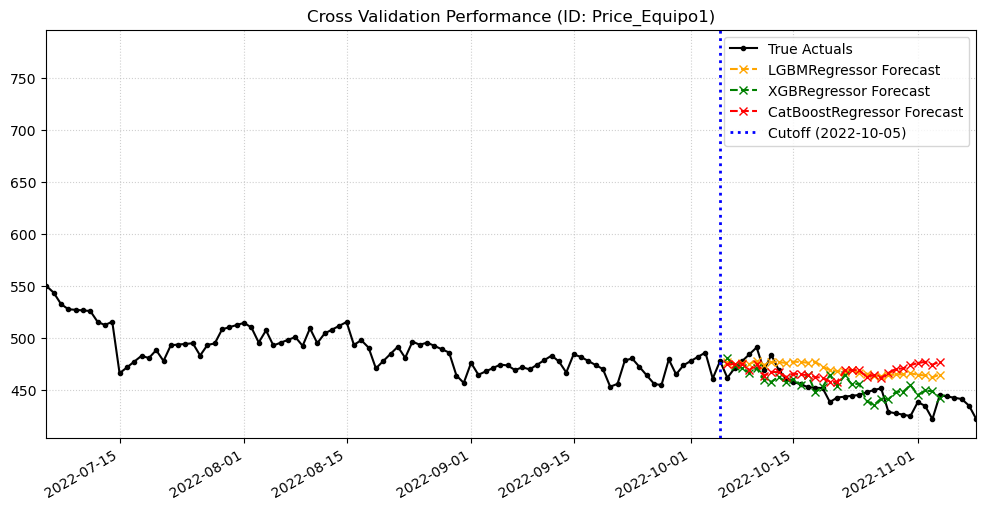

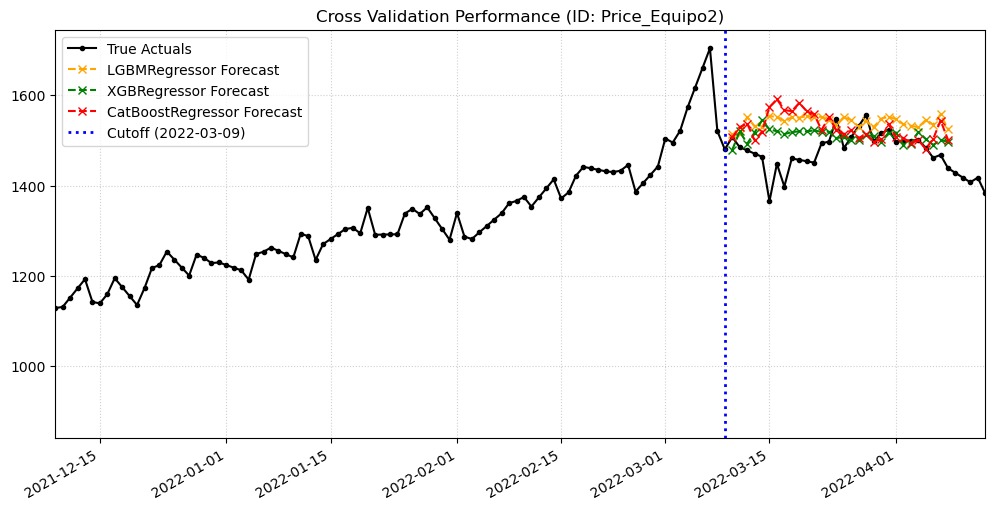

In [38]:

def plot_cv_clean(history_last, cv_results, target_id, cv_window_idx=0, models=['LGBMRegressor']):
    history_last['unique_id'] = history_last['unique_id'].astype(str)
    history_last['ds'] = pd.to_datetime(history_last['ds'])
    cv_results['unique_id'] = cv_results['unique_id'].astype(str)
    cv_results['ds'] = pd.to_datetime(cv_results['ds'])
    cv_results['cutoff'] = pd.to_datetime(cv_results['cutoff'])
    
    hist_uid = history_last[history_last['unique_id'] == target_id].sort_values('ds')
    cv_uid = cv_results[cv_results['unique_id'] == target_id]
    
    unique_cutoffs = sorted(cv_uid['cutoff'].unique())
    selected_cutoff = unique_cutoffs[cv_window_idx]
    
    cv_window = cv_uid[cv_uid['cutoff'] == selected_cutoff].sort_values('ds')
        
    plt.figure(figsize=(12, 6))
    
    plt.plot(hist_uid['ds'], hist_uid['Actual'], label='True Actuals', color='black', marker='.')
    
    # Plot Selected Models
    if isinstance(models, str): models = [models]
    colors = ['orange', 'green', 'red', 'purple']
    
    for i, model in enumerate(models):
        if model in cv_window.columns:
            plt.plot(
                cv_window['ds'], 
                cv_window[model], 
                label=f'{model} Forecast', 
                linestyle='--', 
                marker='x',
                color=colors[i % len(colors)]
            )
            
    plt.axvline(x=selected_cutoff, color='blue', linestyle=':', linewidth=2, label=f'Cutoff ({selected_cutoff.date()})')
    
    start_view = selected_cutoff - pd.DateOffset(months=3)
    end_view = cv_window['ds'].max() + pd.DateOffset(days=5)
    plt.xlim(start_view, end_view)
    
    plt.title(f'Cross Validation Performance (ID: {target_id})')
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.gcf().autofmt_xdate()
    plt.show()

plot_cv_clean(history_last, mlf_cv, target_id='Price_Equipo1', cv_window_idx=9, models=['LGBMRegressor', 'XGBRegressor', 'CatBoostRegressor'])

plot_cv_clean(history_last, mlf_cv, target_id='Price_Equipo2', cv_window_idx=2, models=['LGBMRegressor', 'XGBRegressor', 'CatBoostRegressor'])


# Best Model Selection

In [39]:
df_rank_error = evaluation_mlf[evaluation_mlf['metric'] == 'smape'].copy()
    

model_columns = [col for col in df_rank_error.columns if col not in ['unique_id', 'metric', 'cutoff']]


ranks = df_rank_error[model_columns].rank(axis=1, ascending=True)

display(ranks)

avg_ranks = ranks.mean()
best_model_by_rank = avg_ranks.idxmin()

# average metric value for the best model
best_model_metric_value = evaluation_mlf[(evaluation_mlf['metric'] == optimization_metric)][best_model_by_rank].mean()
avg_metrics = {}
for metric in metrics_to_use:
    avg_metrics[metric] = evaluation_mlf[(evaluation_mlf['metric'] == metric)][best_model_by_rank].mean()

for model, rank in avg_ranks.items():
    print(f"  - {model}: {rank:.4f}")

#print the results and all thmetrics fo
print(f"Best model by average rank: {best_model_by_rank} with an average rank of {avg_ranks[best_model_by_rank]:.2f} in the cross validation and an average metrics of: \n")
for metric, value in avg_metrics.items():
    if metrics_to_use[metric] == 'percentual':
        print(f"  - {metric}: {100*value:.2f}%")
    else:
        print(f"  - {metric}: {value:.2f}")


,LGBMRegressor,CatBoostRegressor,XGBRegressor
0,1.0,3.0,2.0
1,1.0,2.0,3.0
2,3.0,1.0,2.0
3,2.0,3.0,1.0
4,3.0,1.0,2.0
5,3.0,2.0,1.0
6,3.0,2.0,1.0
7,3.0,2.0,1.0
8,3.0,1.0,2.0
9,2.0,3.0,1.0


  - LGBMRegressor: 2.0750
  - CatBoostRegressor: 2.0250
  - XGBRegressor: 1.9000
Best model by average rank: XGBRegressor with an average rank of 1.90 in the cross validation and an average metrics of: 

  - smape: 2.41%
  - mape: 4.80%
  - rmse: 47.24
  - mae: 40.60


# Recuperar lags futuros para forecast


In [40]:
display(future_lags)

,ds,Price_Y_lookback_365,Price_Z_lookback_365
4988,2023-09-01,564.210000,2305.750000
4989,2023-09-02,556.320000,2308.500000
4990,2023-09-03,556.670000,2302.416667
4991,2023-09-04,557.020000,2296.333333
4992,2023-09-05,557.370000,2290.250000
4993,2023-09-06,557.630000,2259.000000
4994,2023-09-07,552.630000,2230.250000
4995,2023-09-08,568.240000,2255.750000
4996,2023-09-09,570.000000,2279.750000
4997,2023-09-10,570.000000,2282.583333


## Seasonal Components

In [41]:
seasonal_columns = ['seasonal_' + col for col in targets+exog_features]
seasonal_df = history[['Date'] +  seasonal_columns]


seasonal_future_df = seasonal_df[seasonal_df['Date'].isin(future_lags['ds'] - pd.DateOffset(years=1))].copy()
seasonal_future_df['Date'] = seasonal_future_df['Date'] + pd.DateOffset(years=1)
seasonal_future_df = seasonal_future_df.rename(columns={'Date': 'ds'})
display(seasonal_future_df.head(future_horizon))

,ds,seasonal_Price_Equipo1,seasonal_Price_Equipo2,seasonal_Price_Y,seasonal_Price_Z
4623,2023-09-01,-4.402828,0.256619,-4.618296,-4.233456
4624,2023-09-02,-5.668840,-0.207765,-4.926629,-9.451205
4625,2023-09-03,-1.707703,-3.759266,-4.805956,-19.689304
4626,2023-09-04,-2.156802,1.652534,-3.127873,-9.587877
4627,2023-09-05,-3.303244,-6.259789,-3.326616,-10.136081
4628,2023-09-06,-0.662455,0.131778,-2.659984,-11.185286
4629,2023-09-07,3.571486,-0.778653,-1.545323,-7.940129
4630,2023-09-08,0.918878,-8.027839,-1.419022,-15.038369
4631,2023-09-09,-1.352067,-6.579878,-2.918067,-15.058467
4632,2023-09-10,-4.784044,-3.148314,-3.642433,-4.852109


## merge future features

In [42]:
base_future_features = future_lags.merge(seasonal_future_df, on='ds', how='left')
future_features_1 = base_future_features.copy()
future_features_1['unique_id'] = targets[0] # 'Price_Equipo1'

future_features_2 = base_future_features.copy()
future_features_2['unique_id'] = targets[1] # 'Price_Equipo2'

#append the two future features dataframes
future_features = pd.concat([future_features_1, future_features_2], ignore_index=True)
display(future_features)



,ds,Price_Y_lookback_365,Price_Z_lookback_365,seasonal_Price_Equipo1,seasonal_Price_Equipo2,seasonal_Price_Y,seasonal_Price_Z,unique_id
0,2023-09-01,564.210000,2305.750000,-4.402828,0.256619,-4.618296,-4.233456,Price_Equipo1
1,2023-09-02,556.320000,2308.500000,-5.668840,-0.207765,-4.926629,-9.451205,Price_Equipo1
2,2023-09-03,556.670000,2302.416667,-1.707703,-3.759266,-4.805956,-19.689304,Price_Equipo1
3,2023-09-04,557.020000,2296.333333,-2.156802,1.652534,-3.127873,-9.587877,Price_Equipo1
4,2023-09-05,557.370000,2290.250000,-3.303244,-6.259789,-3.326616,-10.136081,Price_Equipo1
5,2023-09-06,557.630000,2259.000000,-0.662455,0.131778,-2.659984,-11.185286,Price_Equipo1
6,2023-09-07,552.630000,2230.250000,3.571486,-0.778653,-1.545323,-7.940129,Price_Equipo1
7,2023-09-08,568.240000,2255.750000,0.918878,-8.027839,-1.419022,-15.038369,Price_Equipo1
8,2023-09-09,570.000000,2279.750000,-1.352067,-6.579878,-2.918067,-15.058467,Price_Equipo1
9,2023-09-10,570.000000,2282.583333,-4.784044,-3.148314,-3.642433,-4.852109,Price_Equipo1


# Forecast

In [43]:
fcst.models = [model_dictionary[best_model_by_rank]]
fcst = MLForecast(
    models=[model_dictionary[best_model_by_rank]],
    freq='D',
    date_features=['year', 'month', 'dayofweek', 'dayofyear'],
    lags=[1, 7, 30, 365], 
)

fcst.fit(history_augmented, static_features=[], prediction_intervals=PredictionIntervals(n_windows=50, h=future_horizon) )
future_forecast = fcst.predict(future_horizon, X_df=future_features, level=[0.95])

future_forecast.columns = ['unique_id', 'ds', 'forecast', 'lower_95', 'upper_95']

display(future_forecast)

,unique_id,ds,forecast,lower_95,upper_95
0,Price_Equipo1,2023-09-01,451.500977,451.335676,451.666277
1,Price_Equipo1,2023-09-02,449.255371,449.225173,449.285569
2,Price_Equipo1,2023-09-03,457.172791,456.882312,457.463269
3,Price_Equipo1,2023-09-04,459.824036,459.529581,460.118491
4,Price_Equipo1,2023-09-05,456.020416,455.883707,456.157126
5,Price_Equipo1,2023-09-06,461.665039,461.601070,461.729008
6,Price_Equipo1,2023-09-07,465.505737,465.392325,465.619150
7,Price_Equipo1,2023-09-08,458.441376,457.056013,459.826739
8,Price_Equipo1,2023-09-09,453.629120,453.271917,453.986323
9,Price_Equipo1,2023-09-10,451.924225,451.886769,451.961680


### plot 

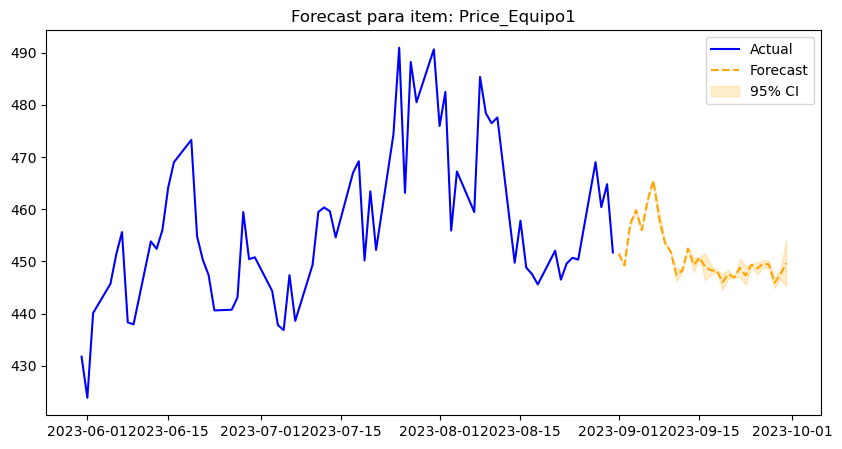

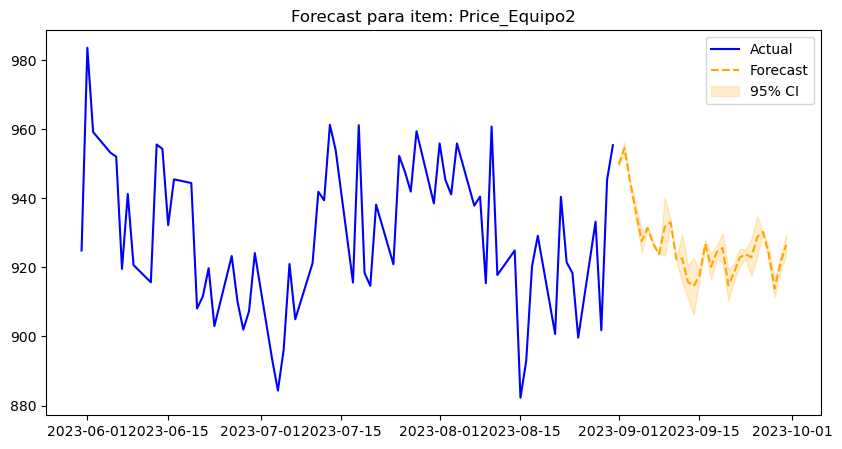

In [44]:


def plot_forecasts(history_last, future_forecast, M_months):

    history_last['unique_id'] = history_last['unique_id'].astype(str)
    future_forecast['unique_id'] = future_forecast['unique_id'].astype(str)
    future_forecast['ds'] = pd.to_datetime(future_forecast['ds'])
    
    unique_ids = future_forecast['unique_id'].unique()
    
    for uid in unique_ids:
        hist_uid = history_last[history_last['unique_id'] == uid]
        fcst_uid = future_forecast[future_forecast['unique_id'] == uid]
        
        if not hist_uid.empty:
            cutoff = hist_uid['ds'].max() - pd.DateOffset(months=M_months)
            hist_uid = hist_uid[hist_uid['ds'] >= cutoff]
            
        plt.figure(figsize=(10, 5))
        
        plt.plot(hist_uid['ds'], hist_uid['Actual'], label='Actual', color='blue')
        plt.plot(fcst_uid['ds'], fcst_uid['forecast'], label='Forecast', color='orange', linestyle='--')
        
        plt.fill_between(
            fcst_uid['ds'], 
            fcst_uid['lower_95'], 
            fcst_uid['upper_95'], 
            color='orange', 
            alpha=0.2, 
            label='95% CI'
        )
        
        plt.title(f'Forecast para item: {uid}')
        plt.legend()
        plt.show()

plot_forecasts(history_last, future_forecast, M_months=3)

### Guardar Forecast en CSV

In [45]:

future_forecast.to_csv(f'./future_forecast_{max_date}_dates.csv', index=False)